BANKA MÜŞTERİ KAYBETME TAHMİNİ-MAKİNE ÖĞRENMESİ


In [151]:
#!pip install pandas numpy scikit-learn seaborn matplotlib imbalanced-learn


In [171]:
import pandas as pd 
import numpy as np 
import seaborn as sns

In [172]:
customerData=pd.read_csv('ChurnModel.csv')
customerData

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [173]:
#Display Top 5 Rows of The Dataset

customerData.head() #exited müşterinin bankadan ayrılıp ayrılmadığı anlamına gelir(bağımlı değişken)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [174]:
#Check Last 5 Rows of The Dataset 

customerData.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


RowNumber:Satır numarası-
CustomerId:Müşteri kimliği-
Surname:Soyadı-
CreditScore:Kredi Puanı-
Geography:Coğrafya-
Gende:Cinsiyet-
Age:Yaş-
Tenure:Görev süresi-
Balance:Bakiye-
NumOfProducts:Ürün sayısı-
HasCrCard:CR kartına sahip mi-
IsActiveMember:Aktif üye-
EstimatedSalary:Tahmini maaş-
Exited:Çıktı

In [175]:
#Find Shape of Our Dataset

customerData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [176]:
#Check Null Values in the dataset

customerData.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [177]:
#get overall statistics about the dataset

customerData.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [178]:
#dropping irrelevant features

customerData.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [179]:
data=customerData.drop(['RowNumber', 'CustomerId', 'Surname'],axis=1)
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [180]:
#Encoding categorical data 
#kategorik verileri dönüştürme (Geography,Gender)
data['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [181]:
data=pd.get_dummies(data,drop_first=True) #Germany ve Spain kaldı ilk sutun kaldırıldı değişken tuzağını görmek için 
data = data.astype(int)
data.head(5)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0,1,1,1,101348,1,0,0,0
1,608,41,1,83807,1,0,1,112542,0,0,1,0
2,502,42,8,159660,3,1,0,113931,1,0,0,0
3,699,39,1,0,2,0,0,93826,0,0,0,0
4,850,43,2,125510,1,1,1,79084,0,0,1,0


In [182]:
#Not Handling Imbalanced
data['Exited'].value_counts() #0 müşterinin ayrılmadığı 1 ise ayrıldığı anlamına gelir 

Exited
0    7963
1    2037
Name: count, dtype: int64

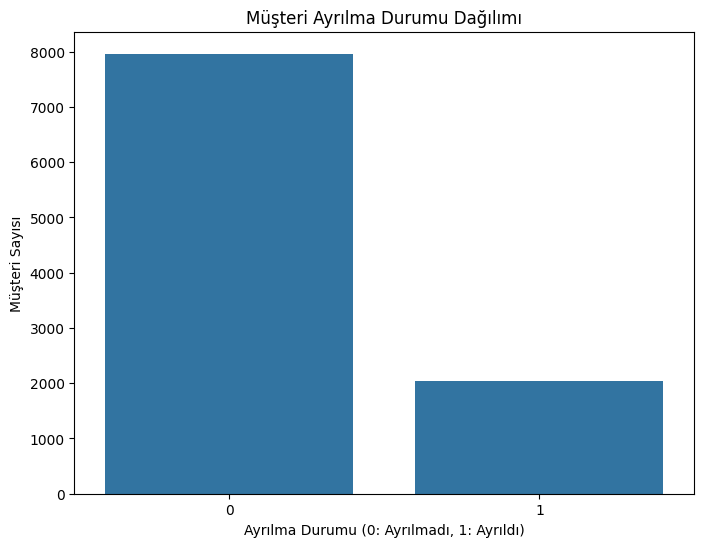

In [183]:
# ... existing code ...

import seaborn as sns
import matplotlib.pyplot as plt  # matplotlib'i import ediyoruz

# Grafiği çizme
plt.figure(figsize=(8, 6))  # grafik boyutunu ayarlama (opsiyonel)
sns.countplot(x='Exited', data=data)
plt.title('Müşteri Ayrılma Durumu Dağılımı')
plt.xlabel('Ayrılma Durumu (0: Ayrılmadı, 1: Ayrıldı)')
plt.ylabel('Müşteri Sayısı')
plt.show()  # grafiği gösterme

# ... existing code ...

In [184]:
X=data.drop('Exited',axis=1)
y=data['Exited']
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int32

In [185]:
#Handling Imbalanced Data With SMOTE 

from imblearn.over_sampling import SMOTE
X_res,y_res=SMOTE().fit_resample(X,y)
y_res.value_counts()

Exited
1    7963
0    7963
Name: count, dtype: int64

In [186]:
print(X_res.shape)  # Özellik (features) veri kümesinin boyutları
print(y_res.shape)  # Etiket (labels) veri kümesinin boyutları


(15926, 11)
(15926,)


In [188]:
#Splitting the dataset into the training set and test set 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.20, random_state=42, stratify=y_res
)


In [189]:
#feature Scaling
from sklearn.preprocessing import StandardScaler  # Yazım hatası düzeltildi
sc= StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [190]:
X_train


array([[-0.56265958,  0.60288556,  0.44006809, ..., -0.56731914,
        -0.46275562,  1.19288495],
       [ 0.30900859, -1.49508278, -1.39199106, ...,  1.7626763 ,
        -0.46275562, -0.83830381],
       [ 0.58140489, -1.99459905,  1.53930357, ..., -0.56731914,
         2.16096782, -0.83830381],
       ...,
       [ 0.11288325, -0.99556651, -0.6591674 , ...,  1.7626763 ,
        -0.46275562, -0.83830381],
       [-0.27936742,  0.10336929,  0.07365626, ..., -0.56731914,
        -0.46275562, -0.83830381],
       [ 0.03661229, -0.69585675, -0.29275557, ..., -0.56731914,
        -0.46275562,  1.19288495]])

In [191]:
#Logistic regresyon 
from sklearn.linear_model import LogisticRegression
log=LogisticRegression()
log.fit(X_train,y_train)

LogisticRegression()

In [192]:
y_pred1=log.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred1)


0.775894538606403

In [193]:
from sklearn.metrics import precision_score,recall_score,f1_score
precision_score(y_test,y_pred1)

0.7714638665843113

In [194]:
recall_score(y_test,y_pred1)

0.7840552416823603

In [195]:
f1_score(y_test,y_pred1)

0.7777085927770859

In [196]:
#pc=TP/(FP+TP)
#rc=TP/(TP+FN)

In [197]:
#SVC
from sklearn import svm 
svm= svm.SVC()
svm.fit(X_train,y_train)

SVC()

In [198]:
y_pred2=svm.predict(X_test)
accuracy_score(y_test,y_pred2)

0.8254865034526051

In [199]:
precision_score(y_test,y_pred2)

0.8254865034526051

In [200]:
#KNeighbors Classifier

from sklearn.neighbors import KNeighborsClassifier
knn= KNeighborsClassifier()
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [201]:
y_pred3=knn.predict(X_test)
accuracy_score(y_test,y_pred3)

0.8185812931575643

In [202]:
precision_score(y_test,y_pred3)

0.8081360048573163

In [203]:
#Decision Tress Classifier 

from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)


DecisionTreeClassifier()

In [206]:
y_pred4=dt.predict(X_test)
accuracy_score(y_test,y_pred4)

0.8000627746390458

In [207]:
precision_score(y_test,y_pred4)

0.7896969696969697

In [208]:
#Random Forest Classifier 

from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

In [209]:
y_pred5=rf.predict(X_test)
accuracy_score(y_test,y_pred5)

0.8502824858757062

In [210]:
#Gradient Boosting Classifier 

from sklearn.ensemble import GradientBoostingClassifier
gbc=GradientBoostingClassifier()
gbc.fit(X_train,y_train)

GradientBoostingClassifier()

In [212]:
y_pred6=gbc.predict(X_test)
accuracy_score(y_test,y_pred5)

0.8502824858757062

In [213]:
precision_score(y_test,y_pred6)


0.8394348105330764

In [218]:
final_data=pd.DataFrame({'Models':['LR','SVC','KNN','DT','RF','GBC'],
                        'ACC':[accuracy_score(y_test,y_pred1),
                               accuracy_score(y_test,y_pred2),
                               accuracy_score(y_test,y_pred3),
                               accuracy_score(y_test,y_pred4),
                               accuracy_score(y_test,y_pred5),
                               accuracy_score(y_test,y_pred6)]})
final_data

,Models,ACC
0,LR,0.775895
1,SVC,0.825487
2,KNN,0.818581
3,DT,0.800063
4,RF,0.850282
5,GBC,0.831764


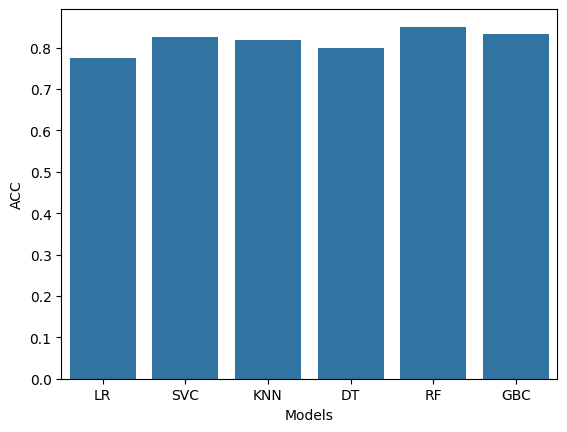

In [220]:
import seaborn as sns
sns.barplot(x="Models", y="ACC", data=final_data)
plt.show()

In [221]:
final_data=pd.DataFrame({'Models':['LR','SVC','KNN','DT','RF','GBC'],
                        'PRE':[precision_score(y_test,y_pred1),
                               precision_score(y_test,y_pred2),
                               precision_score(y_test,y_pred3),
                               precision_score(y_test,y_pred4),
                               precision_score(y_test,y_pred5),
                               precision_score(y_test,y_pred6)]})
final_data



,Models,PRE
0,LR,0.771464
1,SVC,0.825487
2,KNN,0.808136
3,DT,0.789697
4,RF,0.851828
5,GBC,0.839435


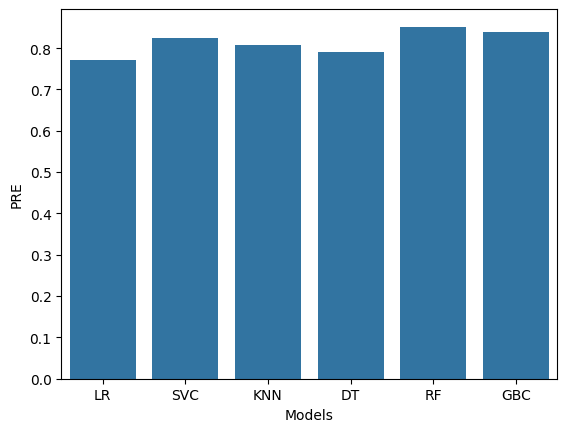

In [223]:
sns.barplot(x="Models", y="PRE", data=final_data)
plt.show()

In [225]:
#Save The Model 
from imblearn.over_sampling import SMOTE
X_res,y_res =SMOTE().fit_resample(X,y)
y_res.value_counts()

Exited
1    7963
0    7963
Name: count, dtype: int64

In [226]:
X_res=sc.fit_transform(X_res)
rf.fit(X_res,y_res)

RandomForestClassifier()

In [227]:
#Save the model 
import joblib
joblib.dump(rf,'churn_predict_model')

['churn_predict_model']

In [228]:
model=joblib.load('churn_predict_model')

In [229]:
data.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='object')

In [230]:
model.predict([[619,42,2,0.0,0,0,0,101348.88,0,0,0]])

array([1])

In [232]:
#GUI

from tkinter import * 
from sklearn.preprocessing import StandardScaler 
import joblib 

In [240]:
import joblib
import tkinter as tk
from tkinter import Button, Entry, messagebox
import numpy as np

# Tkinter pencere oluşturma
master = tk.Tk()
master.title("Müşteri Churn Tahmini")

# Label ve Entry kutuları ekleme
labels = [
    "CreditScore", "Age", "Tenure", "Balance", "NumOfProducts",
    "HasCrCard (0/1)", "IsActiveMember (0/1)", "EstimatedSalary",
    "Geography (1: Germany, 2: Spain, 3: France)", "Gender (0: Female, 1: Male)"
]

entries = {}  # Entry kutularını saklamak için sözlük

for i, label in enumerate(labels):
    tk.Label(master, text=label).grid(row=i, column=0, padx=5, pady=3)
    entries[label] = Entry(master)
    entries[label].grid(row=i, column=1, padx=5, pady=3)

# Model ve scaler yükleme
model = joblib.load('churn_predict_model')  # Model dosyanın uzantısını kontrol et!



def show_entry_field():
    try:
        # Girdileri al ve veri türlerini kontrol et
        p1 = int(entries["CreditScore"].get())
        p2 = int(entries["Age"].get())
        p3 = int(entries["Tenure"].get())
        p4 = float(entries["Balance"].get())
        p5 = int(entries["NumOfProducts"].get())
        p6 = int(entries["HasCrCard (0/1)"].get())
        p7 = int(entries["IsActiveMember (0/1)"].get())
        p8 = float(entries["EstimatedSalary"].get())
        p9 = int(entries["Geography (1: Germany, 2: Spain, 3: France)"].get())
        p10 = int(entries["Gender (0: Female, 1: Male)"].get())

        # Ülke kodlaması (One-Hot Encoding)
        Geography_Germany = 1 if p9 == 1 else 0
        Geography_Spain = 1 if p9 == 2 else 0
        # Fransa için değişken tanımlamaya gerek yok, çünkü otomatik 0 olacak.

        # Model tahmini için veri hazırla
        input_data = np.array([[p1, p2, p3, p4, p5, p6, p7, p8, Geography_Germany, Geography_Spain, p10]])
        input_data_scaled = sc.transform(input_data)  # Scaler ile dönüştür

        result = model.predict(input_data_scaled)[0]  # İlk sonucu al

        # Sonucu gösterme
        if result == 0:
            messagebox.showinfo("Sonuç", "Müşteri kaybetme olasılığı düşük.")
        else:
            messagebox.showwarning("Sonuç", "Müşteri kaybetme olasılığı yüksek!")

    except ValueError:
        messagebox.showerror("Hata", "Lütfen tüm girişleri doğru formatta girin!")


# Buton ekleme
Button(master, text='Predict', command=show_entry_field).grid(row=len(labels), column=1, pady=10)

# Tkinter ana döngüsü
master.mainloop()


In [243]:
import joblib
import tkinter as tk
from tkinter import Button, Entry, messagebox
import numpy as np

# Tkinter pencere oluşturma
master = tk.Tk()
master.title("Müşteri Churn Tahmini")

# Label ve Entry kutuları ekleme
labels = [
    "CreditScore", "Age", "Tenure", "Balance", "NumOfProducts",
    "HasCrCard (0/1)", "IsActiveMember (0/1)", "EstimatedSalary",
    "Geography (1: Germany, 2: Spain, 3: France)", "Gender (0: Female, 1: Male)"
]

entries = {}  # Entry kutularını saklamak için sözlük

for i, label in enumerate(labels):
    tk.Label(master, text=label).grid(row=i, column=0, padx=5, pady=3)
    entries[label] = Entry(master)
    entries[label].grid(row=i, column=1, padx=5, pady=3)

# Model ve scaler yükleme
try:
    model = joblib.load('churn_predict_model')  # Model dosyasını yükle
except Exception as e:
    messagebox.showerror("Hata", f"Model veya scaler yüklenirken hata oluştu: {e}")
    master.destroy()

def get_user_inputs():
    """Kullanıcı girdilerini alır ve kontrol eder."""
    try:
        inputs = []
        for label in labels:
            value = entries[label].get()
            if label in ["CreditScore", "Age", "Tenure", "NumOfProducts", "HasCrCard (0/1)", "IsActiveMember (0/1)", "Geography (1: Germany, 2: Spain, 3: France)", "Gender (0: Female, 1: Male)"]:
                inputs.append(int(value))
            else:
                inputs.append(float(value))
        return inputs
    except ValueError:
        messagebox.showerror("Hata", "Lütfen tüm girişleri doğru formatta girin!")
        return None

def prepare_input_data(inputs):
    """Kullanıcı girdilerini model için hazırlar."""
    p1, p2, p3, p4, p5, p6, p7, p8, p9, p10 = inputs

    # Ülke kodlaması (One-Hot Encoding)
    Geography_Germany = 1 if p9 == 1 else 0
    Geography_Spain = 1 if p9 == 2 else 0

    # Model tahmini için veri hazırla
    input_data = np.array([[p1, p2, p3, p4, p5, p6, p7, p8, Geography_Germany, Geography_Spain, p10]])
    input_data_scaled = sc.transform(input_data)  # Scaler ile dönüştür

    return input_data_scaled

def predict_churn():
    """Modeli kullanarak churn tahmini yapar ve sonucu gösterir."""
    inputs = get_user_inputs()
    if inputs is None:
        return

    input_data_scaled = prepare_input_data(inputs)
    result = model.predict(input_data_scaled)[0]  # İlk sonucu al

    # Sonucu gösterme
    if result == 0:
        messagebox.showinfo("Sonuç", "Müşteri kaybetme olasılığı düşük.")
    else:
        messagebox.showwarning("Sonuç", "Müşteri kaybetme olasılığı yüksek!")

# Buton ekleme
Button(master, text='Predict', command=predict_churn).grid(row=len(labels), column=1, pady=10)

# Tkinter ana döngüsü
master.mainloop()

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
